In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bond_price(face_value, coupon_rate, ytm, years, frequency=2):
    periods = int(years * frequency)
    coupon = face_value * coupon_rate / frequency
    periodic_yield = ytm / frequency

    price = 0

    for t in range(1, periods + 1):
        price += coupon / (1 + periodic_yield) ** t

    price += face_value / (1 + periodic_yield) ** periods

    return price

In [3]:
face_value = 100
coupon_rate = 0.04
ytm = 0.045
years = 5
frequency = 2

price = bond_price(
    face_value,
    coupon_rate,
    ytm,
    years,
    frequency
)

print(f"Bond Price: {price:.4f}")

Bond Price: 97.7834


In [4]:
def macaulay_duration(face_value, coupon_rate, ytm, years, frequency=2):
    periods = int(years * frequency)
    coupon = face_value * coupon_rate / frequency
    periodic_yield = ytm / frequency

    price = bond_price(
        face_value,
        coupon_rate,
        ytm,
        years,
        frequency
    )

    weighted_pv = 0

    for t in range(1, periods + 1):
        cash_flow = coupon

        if t == periods:
            cash_flow += face_value

        pv = cash_flow / (1 + periodic_yield) ** t

        time_years = t / frequency

        weighted_pv += time_years * pv

    duration = weighted_pv / price

    return duration

In [5]:
mac_duration = macaulay_duration(
    face_value,
    coupon_rate,
    ytm,
    years,
    frequency
)

print(f"Macaulay Duration: {mac_duration:.4f} years")

Macaulay Duration: 4.5753 years


In [6]:
def modified_duration(macaulay_duration, ytm, frequency=2):
    return macaulay_duration / (1 + ytm / frequency)

In [7]:
mod_duration = modified_duration(
    mac_duration,
    ytm,
    frequency
)

print(f"Modified Duration: {mod_duration:.4f}")

Modified Duration: 4.4747


In [8]:
def dv01(price, modified_duration, face_value=100):
    return modified_duration * price * 0.0001

bond_dv01 = dv01(
    price,
    mod_duration
)

print(f"DV01 per $100 face value: {bond_dv01:.4f}")

DV01 per $100 face value: 0.0438


In [9]:
position_notional = 1_000_000

position_dv01 = bond_dv01 * (position_notional / face_value)

print(f"Position DV01: ${position_dv01:,.2f}")

Position DV01: $437.55


In [10]:
yield_shock_bp = 10

estimated_pnl = -position_dv01 * yield_shock_bp

print(
    f"Estimated P&L for a +{yield_shock_bp} bp yield shock: "
    f"${estimated_pnl:,.2f}"
)

Estimated P&L for a +10 bp yield shock: $-4,375.48


In [11]:
def bond_convexity(face_value, coupon_rate, ytm, years, frequency=2):
    periods = int(years * frequency)
    coupon = face_value * coupon_rate / frequency
    periodic_yield = ytm / frequency

    price = bond_price(
        face_value,
        coupon_rate,
        ytm,
        years,
        frequency
    )

    convexity_sum = 0

    for t in range(1, periods + 1):
        cash_flow = coupon

        if t == periods:
            cash_flow += face_value

        convexity_sum += (
            cash_flow * t * (t + 1)
            / (1 + periodic_yield) ** (t + 2)
        )

    convexity = convexity_sum / (price * frequency ** 2)

    return convexity

In [12]:
convexity = bond_convexity(
    face_value,
    coupon_rate,
    ytm,
    years,
    frequency
)

print(f"Convexity: {convexity:.4f}")

Convexity: 23.3462


In [13]:
shock_bp = 50
shock = shock_bp / 10000

new_ytm = ytm + shock

new_price = bond_price(
    face_value,
    coupon_rate,
    new_ytm,
    years,
    frequency
)

exact_price_change = new_price - price

duration_estimate = (
    -mod_duration * shock * price
)

duration_convexity_estimate = (
    (
        -mod_duration * shock
        + 0.5 * convexity * shock ** 2
    )
    * price
)

print(f"Original Price: {price:.4f}")
print(f"New Price: {new_price:.4f}")
print(f"Exact Price Change: {exact_price_change:.4f}")
print(f"Duration Estimate: {duration_estimate:.4f}")
print(
    f"Duration + Convexity Estimate: "
    f"{duration_convexity_estimate:.4f}"
)

Original Price: 97.7834
New Price: 95.6240
Exact Price Change: -2.1595
Duration Estimate: -2.1877
Duration + Convexity Estimate: -2.1592


In [14]:
shock_bps = [-100, -75, -50, -25, 0, 25, 50, 75, 100]

shock_results = []

for shock_bp in shock_bps:
    shock = shock_bp / 10000
    shocked_ytm = ytm + shock

    exact_new_price = bond_price(
        face_value,
        coupon_rate,
        shocked_ytm,
        years,
        frequency
    )

    exact_change = exact_new_price - price

    duration_change = (
        -mod_duration * shock * price
    )

    duration_convexity_change = (
        (
            -mod_duration * shock
            + 0.5 * convexity * shock ** 2
        )
        * price
    )

    shock_results.append({
        "Yield Shock (bp)": shock_bp,
        "Exact Price Change": exact_change,
        "Duration Estimate": duration_change,
        "Duration + Convexity Estimate": duration_convexity_change
    })

shock_table = pd.DataFrame(shock_results).round(4)

shock_table

,Yield Shock (bp),Exact Price Change,Duration Estimate,Duration + Convexity Estimate
0,-100,4.4919,4.3755,4.4896
1,-75,3.3468,3.2816,3.3458
2,-50,2.2166,2.1877,2.2163
3,-25,1.1010,1.0939,1.1010
4,0,0.0000,-0.0000,0.0000
5,25,-1.0868,-1.0939,-1.0867
6,50,-2.1595,-2.1877,-2.1592
7,75,-3.2183,-3.2816,-3.2174
8,100,-4.2635,-4.3755,-4.2613


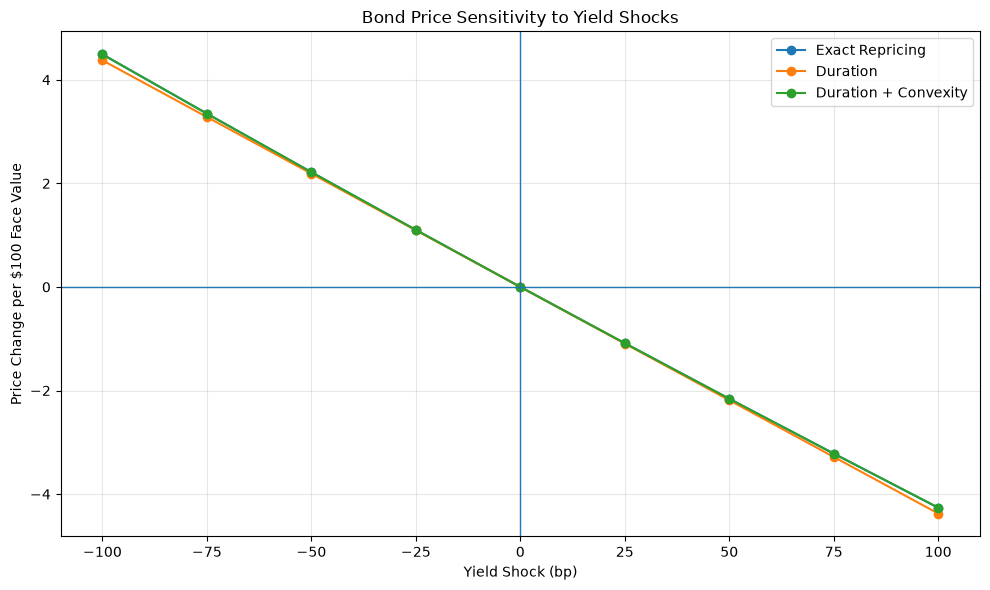

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    shock_table["Yield Shock (bp)"],
    shock_table["Exact Price Change"],
    marker="o",
    label="Exact Repricing"
)

plt.plot(
    shock_table["Yield Shock (bp)"],
    shock_table["Duration Estimate"],
    marker="o",
    label="Duration"
)

plt.plot(
    shock_table["Yield Shock (bp)"],
    shock_table["Duration + Convexity Estimate"],
    marker="o",
    label="Duration + Convexity"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Bond Price Sensitivity to Yield Shocks")
plt.xlabel("Yield Shock (bp)")
plt.ylabel("Price Change per $100 Face Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/bond_price_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [17]:
portfolio = pd.DataFrame({
    "Bond": ["2Y Bond", "5Y Bond", "10Y Bond"],
    "Face Value": [100, 100, 100],
    "Coupon Rate": [0.040, 0.045, 0.050],
    "YTM": [0.04619, 0.04656, 0.05023],
    "Years": [2, 5, 10],
    "Frequency": [2, 2, 2],
    "Notional": [2_000_000, 3_000_000, 1_500_000]
})

portfolio

,Bond,Face Value,Coupon Rate,YTM,Years,Frequency,Notional
0,2Y Bond,100,0.040,0.04619,2,2,2000000
1,5Y Bond,100,0.045,0.04656,5,2,3000000
2,10Y Bond,100,0.050,0.05023,10,2,1500000


In [18]:
portfolio_results = []

for _, bond in portfolio.iterrows():

    price_i = bond_price(
        bond["Face Value"],
        bond["Coupon Rate"],
        bond["YTM"],
        bond["Years"],
        bond["Frequency"]
    )

    mac_i = macaulay_duration(
        bond["Face Value"],
        bond["Coupon Rate"],
        bond["YTM"],
        bond["Years"],
        bond["Frequency"]
    )

    mod_i = modified_duration(
        mac_i,
        bond["YTM"],
        bond["Frequency"]
    )

    conv_i = bond_convexity(
        bond["Face Value"],
        bond["Coupon Rate"],
        bond["YTM"],
        bond["Years"],
        bond["Frequency"]
    )

    market_value = (
        bond["Notional"] * price_i / 100
    )

    position_dv01 = (
        mod_i * market_value * 0.0001
    )

    portfolio_results.append({
        "Bond": bond["Bond"],
        "Notional": bond["Notional"],
        "Price": price_i,
        "Market Value": market_value,
        "Modified Duration": mod_i,
        "Convexity": conv_i,
        "DV01 ($)": position_dv01
    })

portfolio_metrics = pd.DataFrame(portfolio_results)

portfolio_metrics.round(2)

,Bond,Notional,Price,Market Value,Modified Duration,Convexity,DV01 ($)
0,2Y Bond,2000000,98.83,1976606.12,1.90,4.59,375.10
1,5Y Bond,3000000,99.31,2979336.95,4.43,23.00,1319.19
2,10Y Bond,1500000,99.82,1497313.79,7.79,73.59,1166.65


In [19]:
total_dv01 = portfolio_metrics["DV01 ($)"].sum()

total_market_value = portfolio_metrics["Market Value"].sum()

print(f"Portfolio Market Value: ${total_market_value:,.2f}")
print(f"Portfolio DV01: ${total_dv01:,.2f}")

Portfolio Market Value: $6,453,256.86
Portfolio DV01: $2,860.95


In [20]:
shock_bp = 25
shock = shock_bp / 10000

portfolio_shock_results = []

for i, bond in portfolio.iterrows():

    old_price = portfolio_metrics.loc[i, "Price"]
    mod_duration_i = portfolio_metrics.loc[i, "Modified Duration"]
    convexity_i = portfolio_metrics.loc[i, "Convexity"]
    market_value_i = portfolio_metrics.loc[i, "Market Value"]

    new_ytm = bond["YTM"] + shock

    new_price = bond_price(
        bond["Face Value"],
        bond["Coupon Rate"],
        new_ytm,
        bond["Years"],
        bond["Frequency"]
    )

    exact_pnl = (
        (new_price - old_price)
        / 100
        * bond["Notional"]
    )

    duration_convexity_pnl = (
        -mod_duration_i * shock
        + 0.5 * convexity_i * shock ** 2
    ) * market_value_i

    portfolio_shock_results.append({
        "Bond": bond["Bond"],
        "Exact P&L ($)": exact_pnl,
        "Duration + Convexity P&L ($)": duration_convexity_pnl
    })

portfolio_shock = pd.DataFrame(portfolio_shock_results)

portfolio_shock.round(2)

,Bond,Exact P&L ($),Duration + Convexity P&L ($)
0,2Y Bond,-9349.33,-9349.26
1,5Y Bond,-32766.69,-32765.67
2,10Y Bond,-28824.87,-28821.93


In [21]:
print(
    f"Exact Portfolio P&L for +{shock_bp} bp shock: "
    f"${portfolio_shock['Exact P&L ($)'].sum():,.2f}"
)

print(
    f"Duration + Convexity Estimate: "
    f"${portfolio_shock['Duration + Convexity P&L ($)'].sum():,.2f}"
)

Exact Portfolio P&L for +25 bp shock: $-70,940.89
Duration + Convexity Estimate: $-70,936.86


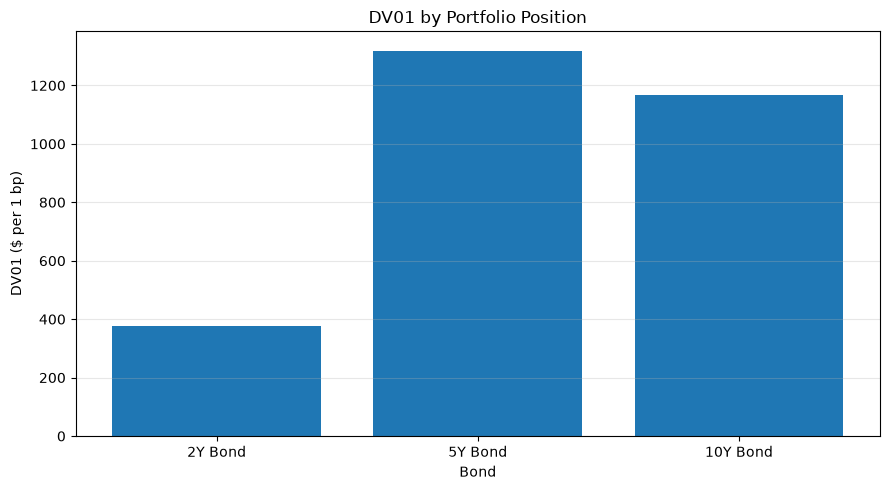

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    portfolio_metrics["Bond"],
    portfolio_metrics["DV01 ($)"]
)

plt.title("DV01 by Portfolio Position")
plt.xlabel("Bond")
plt.ylabel("DV01 ($ per 1 bp)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/portfolio_dv01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

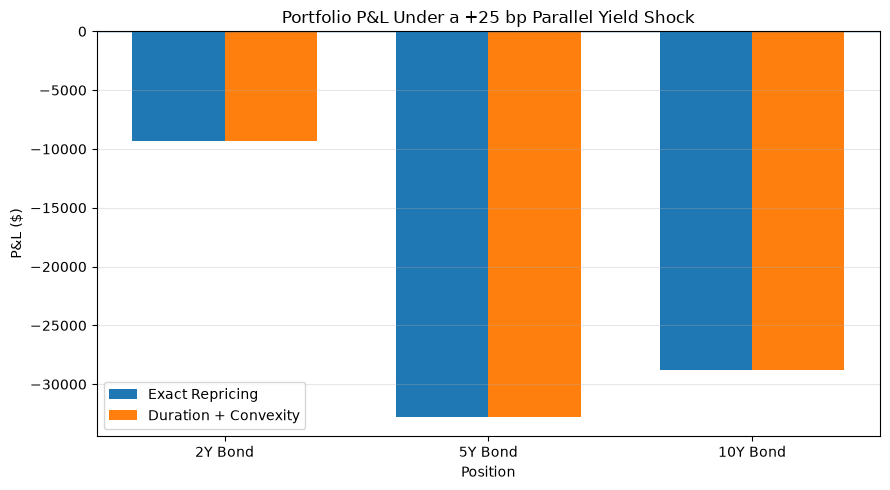

In [23]:
plt.figure(figsize=(9, 5))

x = np.arange(len(portfolio_shock))
width = 0.35

plt.bar(
    x - width / 2,
    portfolio_shock["Exact P&L ($)"],
    width,
    label="Exact Repricing"
)

plt.bar(
    x + width / 2,
    portfolio_shock["Duration + Convexity P&L ($)"],
    width,
    label="Duration + Convexity"
)

plt.xticks(
    x,
    portfolio_shock["Bond"]
)

plt.axhline(0, linewidth=1)

plt.title("Portfolio P&L Under a +25 bp Parallel Yield Shock")
plt.xlabel("Position")
plt.ylabel("P&L ($)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/portfolio_25bp_pnl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
shock_table.to_csv(
    "../outputs/tables/bond_shock_analysis.csv",
    index=False
)

portfolio_metrics.to_csv(
    "../outputs/tables/portfolio_risk_metrics.csv",
    index=False
)

portfolio_shock.to_csv(
    "../outputs/tables/portfolio_25bp_shock.csv",
    index=False
)

print("Component 3 tables saved successfully.")

Component 3 tables saved successfully.


## Risk Interpretation

This component translates changes in interest rates into bond and portfolio P&L.

For the illustrative 5-year bond, the calculated modified duration was approximately 4.47. This implies that a 100 bp increase in yield would produce an approximate 4.47% decline in price before accounting for convexity.

DV01 provides a more direct trading-risk measure by estimating the dollar impact of a 1 bp change in yield. Scaling the bond to a $1 million position converts the theoretical duration measure into an estimate of daily rates exposure.

The shock analysis demonstrates the limitations of duration as a purely linear approximation. For a +50 bp yield shock, duration alone slightly overstated the bond's loss, while the duration-plus-convexity estimate was almost identical to the exact repricing. The difference becomes more important as the size of the yield move increases.

The portfolio analysis extends this framework across illustrative 2-year, 5-year and 10-year positions. DV01 allows the contribution of each maturity to total portfolio interest-rate risk to be compared on a common dollar basis.

The +25 bp parallel shock demonstrates how these exposures translate into portfolio P&L and shows that duration and convexity provide an efficient approximation to full bond repricing.

### Limitations

The portfolio is illustrative rather than an actual trading book. The analysis assumes parallel yield changes for the initial stress test, while real yield curves can steepen, flatten or move differently across maturities. The next component therefore extends the framework to non-parallel Australian rates scenarios.